<a href="https://colab.research.google.com/github/kfafa2018-ux/AIML-1030/blob/main/rasterio_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install rasterio scikit-learn matplotlib numpy pandas
#scikit-learn is used for PCA and K-means along with training, and evaluation functions

In [11]:
#mounting my drive so it can read the data set
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
#  Import Libraries
#I have made note of what each library does underneath
import rasterio
#reads and writes raster geospatial data
import pandas as pd
#works with dataframes to manipulate and analyze data, this is used for DL in this notebook
import numpy as np
#used for numerical computing in python
import matplotlib.pyplot as plt
#vizualizes data
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from rasterio.plot import show

In [13]:
import tensorflow as tf
#tensorflow includes keras and  below torch has been imported
#these are the two main deep learning frameworks
import torch

# Force TensorFlow to use CPU (added due to a cuda error)
tf.config.set_visible_devices([], 'GPU')

In [14]:
# 2. Data Acquisition (Load Landsat Data)
#These are the raster files that will be used as the dataset for the entirety of the notebook
#They cover land images and are basically color coded to evaluate if there is  natural and urban land
#cover of the area in Helsinki, Finland
# each band corresponds to a specific spectral band (blue, green, red, near infrared, shortwave infrared 1, shortwave infrared 2)
band_files = [
    '/content/drive/MyDrive/AIML 1030/Rasterio Project/LC09_L2SP_190018_20260411_20260412_02_T1/LC09_L2SP_190018_20260411_20260412_02_T1_SR_B2.TIF', # Blue
    '/content/drive/MyDrive/AIML 1030/Rasterio Project/LC09_L2SP_190018_20260411_20260412_02_T1/LC09_L2SP_190018_20260411_20260412_02_T1_SR_B3.TIF', # Green
    '/content/drive/MyDrive/AIML 1030/Rasterio Project/LC09_L2SP_190018_20260411_20260412_02_T1/LC09_L2SP_190018_20260411_20260412_02_T1_SR_B4.TIF', # Red
    '/content/drive/MyDrive/AIML 1030/Rasterio Project/LC09_L2SP_190018_20260411_20260412_02_T1/LC09_L2SP_190018_20260411_20260412_02_T1_SR_B5.TIF', # NIR
    '/content/drive/MyDrive/AIML 1030/Rasterio Project/LC09_L2SP_190018_20260411_20260412_02_T1/LC09_L2SP_190018_20260411_20260412_02_T1_SR_B6.TIF', # SWIR1
    '/content/drive/MyDrive/AIML 1030/Rasterio Project/LC09_L2SP_190018_20260411_20260412_02_T1/LC09_L2SP_190018_20260411_20260412_02_T1_SR_B7.TIF'  # SWIR2
]


In [15]:
#  Preprocessing: Stack Bands
# Read bands and stack them into a 3D array (bands, height, width)
print("Stacking bands...")

# Define downsampling factor to reduce memory usage
downsample_factor = 4 # Adjust this value (e.g., 2, 4, 8) to control memory and resolution.
from rasterio.enums import Resampling # Import Resampling enum

#this opens the first band to get metadata (original dimensions)
with rasterio.open(band_files[0]) as src:
    meta = src.meta
    original_height, original_width = src.shape

    # Calculate new dimensions for downsampled image
    #downsaple_factor reduces the image size to manage memory usage
    new_height = original_height // downsample_factor
    new_width = original_width // downsample_factor


    print(f"Original image shape: ({original_height}, {original_width})")
    print(f"Downsampling image to: ({new_height}, {new_width}) using a factor of {downsample_factor}")

    stacked_image = np.zeros((len(band_files), new_height, new_width), dtype='float32')
     #stacked image initializes a 3D numpy array to hold the downsampled bands

#The for loop iterates through each band file and reads the band data
#while resampling it using resampling.bilinear interpolation
#this stacks all the individual bands into a single 3D array
for i, file in enumerate(band_files):
    with rasterio.open(file) as src:
        # Read the band and resample it on the fly
        stacked_image[i] = src.read(
            1,
            out_shape=(new_height, new_width),
            resampling=Resampling.bilinear # Or Resampling.nearest, Resampling.average
        )

# Update height and width variables to reflect the downsampled size for subsequent steps
height, width = new_height, new_width

Stacking bands...
Original image shape: (8151, 8091)
Downsampling image to: (2037, 2022) using a factor of 4


In [16]:
# 4. Preprocessing: Flatten and Normalize
# Shape: (height, width, bands) -> (pixels, bands)
#extracts  dimensions from the stacked image
n_bands, height, width = stacked_image.shape
# Transpose to (height, width, bands)
data = np.transpose(stacked_image, (1, 2, 0))
# Reshape to (pixels, bands)
#it is being reshaped inot a 2D array X
#each row represents a single pixel
#columns represent the spectral reflectance values
#for that pixel across different bands
X = data.reshape(-1, n_bands)

# Replace NoData (often -9999 or 0) with NaN or mean if necessary
# Landsat surface reflectance often uses 0 as fill
X[X == 0] = np.nan
X = np.nan_to_num(X) # Replace NaNs with 0 for scaling

# Normalize the data (Crucial for PCA/KMeans) due to their sensitivity to the scale of input features
#normalization scales the data to have a mean of 0 and an SD of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# 5. Dimensionality Reduction with PCA/SVD
#transforming the set of variables into a smaller set
#that still contains most of the information from the large set
# PCA and SVD are interchangeable for this purpose (PCA uses SVD internally)
print("Reducing dimensions...")
pca = PCA(n_components=3) # Reducing from 6 bands to 3 main components
X_reduced = pca.fit_transform(X_scaled)
#the new array holds the data making subsequent processing like k-means
#more efficient & potentially helps to highlight underlying patterns
#by removing noise

Reducing dimensions...


In [18]:

# 6. Clustering with K-Means
#YAY we are finally at where the UNSUPERVISED learning happens!!!!!
print("Clustering with K-Means...")
# k=4 or 5 is good for water, soil, vegetation, urban
k = 4 #The HYPERPARAMETER!!!!!!
# it means we expect to find 4 distinct land cover types!!!
# Maybe it is the green tea kicking in but I am excited for this
# Science project!!!!! Making sure you see it is me adding the notations
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#ensuring reproducibility with random_state
# running the algorithm with n_init=10 multiple times with different
# centroid seeds to choose the best result
# what the heck is a centroid seed though *scratches head*
# we definitely went over this in class.......
# A centroid seed is basically a random starting position for a cluster
cluster_labels = kmeans.fit_predict(X_reduced)
#the k-means algorithm is trained on the reduced data
#it got "fit" to wear "reduced data"
#each pixel is now assigned a cluster label from 0 to k-1
# the cluster labels are now the output of the unsupervised classification
# so much work in one cell right here,
# thank you K-means you are a very valuable algorithm!!!!

Clustering with K-Means...


### Further Preprocessing: One-Hot Encoding

One-hot encoding is a technique used to convert categorical variables into a numerical format that machine learning algorithms can understand. Each category is transformed into a new binary column, where '1' indicates the presence of that category and '0' indicates its absence. This is particularly useful for nominal categorical data where there is no intrinsic order between categories.

Here, we'll demonstrate one-hot encoding on the `cluster_labels` which can be considered a categorical feature representing different land cover types identified by K-Means.

In [19]:
from sklearn.preprocessing import OneHotEncoder

print("Applying One-Hot Encoding to cluster labels...")

# Reshape cluster_labels from 1D to 2D as required by OneHotEncoder
cluster_labels_reshaped = cluster_labels.reshape(-1, 1)

# Initialize and fit OneHotEncoder
#sparse_output=false ensures the output is a DENSE numpy array, not a sparse matrix
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# handle_unkown is used in the event that of encountering labels not seen while the model was being fit
one_hot_encoded_labels = ohe.fit_transform(cluster_labels_reshaped)
# the encoder learns the UNIQUE categories in cluster labels and then
#transforms them into a binary one-hot representation (its safe to assume guys predominately write code with these names)
# each pixels label will become an array of 4 zeros and a single 1
# we see the transformation in the output below
print("Original cluster labels sample (first 10):", cluster_labels_reshaped[:10].flatten())
print("One-hot encoded labels shape:", one_hot_encoded_labels.shape)
print("One-hot encoded labels sample (first 5 rows):\n", one_hot_encoded_labels[:5])
print("Categories found by encoder:", ohe.categories_)

Applying One-Hot Encoding to cluster labels...
Original cluster labels sample (first 10): [0 0 0 0 0 0 0 0 0 0]
One-hot encoded labels shape: (4118814, 4)
One-hot encoded labels sample (first 5 rows):
 [[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
Categories found by encoder: [array([0, 1, 2, 3], dtype=int32)]


In [20]:
# Reshape the cluster labels back to the original
# image dimensions back to 2D array from 1Dso it can be visualized as an image
cluster_image = cluster_labels.reshape(height, width)
print(f"Cluster image shape: {cluster_image.shape}")

Cluster image shape: (2037, 2022)


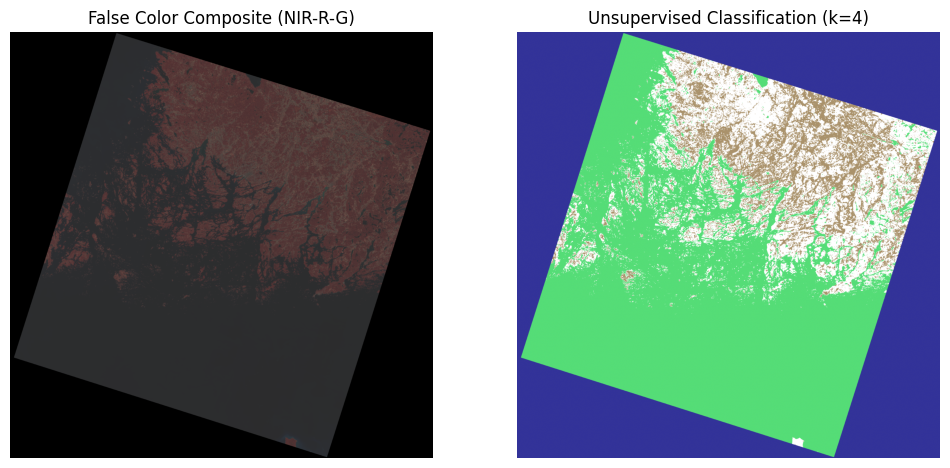

In [21]:
# Plotting
#We are visualizing the results!!!!
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
# Show False Color Composite (NIR, Red, Green) for reference
# The False Color Composite shows vegetation in RED
# Need to normalize bands 5,4,3 for display
rgb = np.dstack((stacked_image[3], stacked_image[2], stacked_image[1]))

# Handle NaNs in rgb before normalization for plotting
rgb_clean = np.nan_to_num(rgb, nan=0.0) # Replace NaNs with 0 for display purposes

rgb_normalized = (rgb_clean - rgb_clean.min()) / (rgb_clean.max() - rgb_clean.min())
plt.imshow(rgb_normalized)
plt.title("False Color Composite (NIR-R-G)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cluster_image, cmap='terrain')
# Cluster_image will display the Unsupervised Classification Map
# Each color represents a different cluster from K-means
# This allows for a visual interpretation of the landcover classification
plt.title(f"Unsupervised Classification (k={k})")
plt.axis('off')

plt.show()
# My first geographical assessment backend AI model
# I am so proud that I can now explain it!!!!!!
# All that green in the unsupervised classification is WATER!!!!

### Evaluating Unsupervised Learning Models

Unlike supervised learning, unsupervised learning models like K-Means do not have ground truth labels to compare against, so traditional 'accuracy' metrics are not applicable. Instead, we use internal clustering validation metrics to evaluate the quality of the clusters. These metrics assess aspects like:

*   **Cohesion**: How tightly grouped the data points within a cluster are.
*   **Separation**: How distinct the clusters are from each other.

One common metric is the **Silhouette Score**, which measures how similar an object is to its own cluster compared to other clusters. It ranges from -1 to 1:

*   **+1**: Implies that the clusters are well-separated.
*   **0**: Implies that clusters are indifferent, or distances between clusters are not significant.
*   **-1**: Implies that clusters are assigned incorrectly.

In [22]:
# Evaluate Clustering (Silhouette Score)
# Again, definitely written by men but important to understand the accuracy of the model

from sklearn.metrics import silhouette_score
from sklearn.utils import resample # Import resample for sampling

print("Calculating Silhouette Score...")

# The Silhouette Score can be computationally intensive for very large datasets.
# For extremely large datasets, consider sampling a subset for evaluation.
# Using X_reduced (PCA-transformed data) for efficiency and better representation.

# Sample a subset of the data for Silhouette Score calculation
sample_size = 700 # You can adjust this sample size
# I set the sample size to 700 because the original 10000 was taking WAY too long to compute

if X_reduced.shape[0] > sample_size:
    # Resample both X_reduced and cluster_labels to maintain correspondence
    X_sample, labels_sample = resample(X_reduced, cluster_labels,
                                       n_samples=sample_size,
                                       random_state=42,
                                       stratify=cluster_labels if sample_size < len(cluster_labels) else None)
else:
    X_sample = X_reduced
    labels_sample = cluster_labels

silhouette_avg = silhouette_score(X_sample, labels_sample)

print(f"The average Silhouette Score is : {silhouette_avg:.3f}")
# the output will show a score of 0.856 which is good because we want it close to 1
# the closer it is to 1 the more well separated & cohesive the clusters are
# Awesome job K-means!!!

Calculating Silhouette Score...
The average Silhouette Score is : 0.856


### Interpreting the Silhouette Score

The calculated Silhouette Score provides an indication of the quality of the clustering. A score closer to 1 suggests that the objects are well matched to their own cluster and poorly matched to neighboring clusters. A score around 0 indicates overlapping clusters, and a negative score means that objects might have been assigned to the wrong clusters.

In addition to quantitative metrics, visual inspection of the cluster map and understanding the characteristics of each cluster (e.g., what land cover types correspond to which cluster) is crucial for a complete evaluation.

### Visualizing Cluster Centroids in Original Feature Space

To better understand what each cluster represents, we can visualize the centroids in terms of their original spectral band values. This involves inverse-transforming the centroids from the PCA-reduced and scaled space back to the original reflectance values. This allows us to see the characteristic spectral signature of each cluster.

In [23]:
# 9. Visualize Cluster Centroids

# Inverse transform the centroids from PCA space
centroids_pca_inverse = pca.inverse_transform(kmeans.cluster_centers_)

# Inverse transform from scaled space to original feature space
centroids_original_scale = scaler.inverse_transform(centroids_pca_inverse)

# Create a DataFrame for better visualization thank you PANDAS!!!!
# You were installed just for this dataframe!!!
bands_names = ['Blue (B2)', 'Green (B3)', 'Red (B4)', 'NIR (B5)', 'SWIR1 (B6)', 'SWIR2 (B7)']
centroids_df = pd.DataFrame(centroids_original_scale, columns=bands_names)
centroids_df.index.name = 'Cluster'

print("Cluster Centroids (Average Reflectance for each Band):")
display(centroids_df)
# The output shows us how K-means was able to cluster land mass by color
# Pretty amazing stuff right here. AI is so much better with SCIENCE!
# one math function is absolutely NOTHING without the meat and potatoes of SCIENCE!!!

Cluster Centroids (Average Reflectance for each Band):


,Blue (B2),Green (B3),Red (B4),NIR (B5),SWIR1 (B6),SWIR2 (B7)
Cluster,,,,,,
0,0.437981,-3.532632,-4.645322,-2.860487,-2.275485,-1.356447
1,7581.389648,7679.887695,7417.801270,7341.597656,7391.605957,7366.220703
2,9200.945312,9984.480469,10640.744141,14198.608398,15252.397461,12968.123047
3,8123.138184,8605.712891,8646.524414,12818.957031,11413.149414,9731.280273


### Interpreting the Centroid Plot

This bar plot shows the average reflectance values for each of the six spectral bands for every cluster. By examining these spectral signatures, you can make informed interpretations about the land cover types associated with each cluster:

*   **High NIR (B5) and low Red (B4) reflectance** often indicates **vegetation**.
*   **High Blue (B2) and Green (B3) but low NIR (B5) and SWIR (B6, B7) reflectance** can indicate **water**.
*   **Relatively uniform reflectance across bands or higher SWIR (B6, B7) reflectance** might indicate **urban areas** or **bare soil**.

Combined with the visual cluster map, this spectral signature analysis allows for a more robust interpretation of your unsupervised classification.

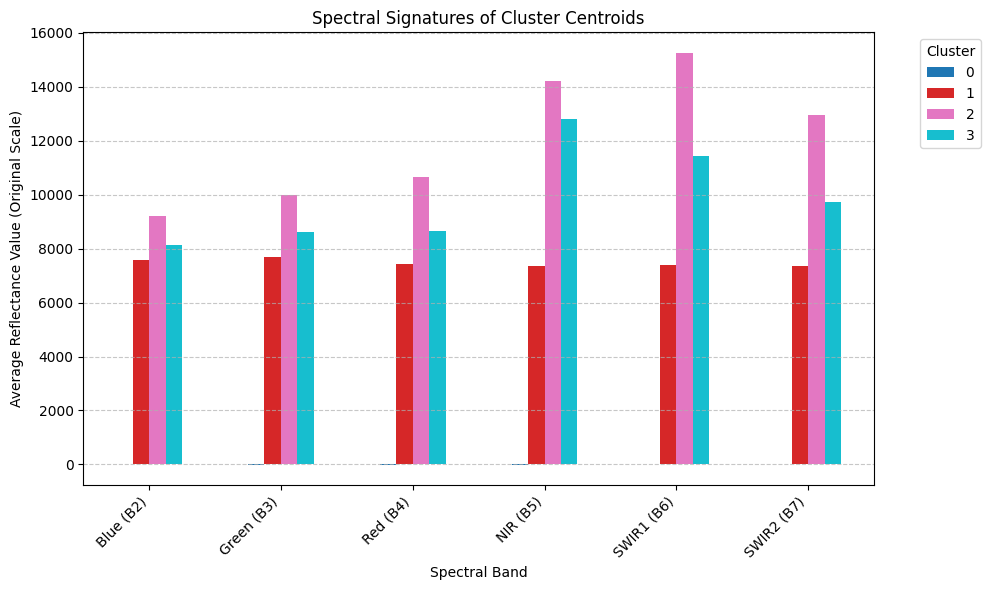

In [24]:
# Plot the centroids
# Visualizing the centroids data framein a bar plot
# so that we can interpret the clusters
# for example we KNOW from the previous
# image that GREEN in this case represents water
# The pink and red represent vegeatation (natural land cover)
# how the computer sees an immage and interprets it thanks to k-means
fig, ax = plt.subplots(figsize=(10, 6))
centroids_df.T.plot(kind='bar', ax=ax, cmap='tab10')
plt.title('Spectral Signatures of Cluster Centroids')
plt.xlabel('Spectral Band')
plt.ylabel('Average Reflectance Value (Original Scale)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Deep Learning Frameworks: Keras and PyTorch

Keras (part of TensorFlow) and PyTorch are popular open-source machine learning libraries for building and training neural networks. While our current task is unsupervised clustering, these frameworks are essential for supervised deep learning tasks, such as image classification or semantic segmentation, which could build upon the features extracted in this notebook.

Here are basic examples of how you might define a simple model in each framework.

### Keras Example

In [25]:
from tensorflow.keras.models import Sequential # it is a feedforward ANN
from tensorflow.keras.layers import Dense # the layers are dense (fully connected like a family tree)

print("Defining a simple Keras Sequential model...")

# Assuming `n_bands` is the number of input features (6 in our case)
# and `k` is the number of output classes (if this were a classification task, e.g., our 4 clusters)

# Get n_bands from the shape of the stacked image data
# This assumes 'stacked_image' is already defined from previous cells.
# If you've run the preprocessing steps, n_bands should be available.
if 'stacked_image' in locals():
    n_bands = stacked_image.shape[0]
else:
    # Fallback if stacked_image is not directly available, assume 6 bands as per context
    n_bands = 6 # Default to 6 if stacked_image not found, adjust if necessary

# Get k from the KMeans model
# This assumes 'kmeans' is already defined from previous cells.
if 'kmeans' in locals():
    k = kmeans.n_clusters
else:
    k = 4 # Default to 4 if kmeans not found, adjust if necessary


keras_model = Sequential([
    Dense(128, activation='relu', input_shape=(n_bands,)), # Input layer with 128 neurons
    Dense(64, activation='relu'),                         # Hidden layer
    Dense(k, activation='softmax')                       # Output layer for `k` classes
])
# the categorical_cross entropy is used here for the one hot labels and because there are more than 2 clusters we are looking at.
# the question for this model is qualitative, not quantitative and refers to the k-means clusters which were 4.
keras_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

keras_model.summary()

Defining a simple Keras Sequential model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,412 (36.77 KB)

 Trainable params: 9,412 (36.77 KB)

 Non-trainable params: 0 (0.00 B)

### PyTorch Example

In [26]:
# Here is the pytorch model
# it is making a simple ANN by first importing torch as nn
import torch.nn as nn
import torch.nn.functional as F

print("Defining a simple PyTorch neural network...")

# Define a simple Neural Network class
# this is done by using nn.module,
# the base class for all neural network modules in Pytorch (pretty important for an AI student to know)
class SimpleNN(nn.Module):
  #we see 3 layers  that are fully connected (linear)
    def __init__(self, input_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128) # input size is our band raster data
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes) #num_classes calls K

    def forward(self, x): # defines the forawrd pass of the network
        x = F.relu(self.fc1(x)) #relu is an important activation function because it outputs the input directly if positive, otherwise it outputs zero
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Assuming `n_bands` is the input feature size and `k` is the number of output classes
# Get n_bands from the shape of the stacked image data
# This assumes 'stacked_image' is already defined from previous cells.
# If you've run the preprocessing steps, n_bands should be available.
if 'stacked_image' in locals():
    input_size = stacked_image.shape[0]
else:
    # Fallback if stacked_image is not directly available, assume 6 bands as per context
    input_size = 6 # Default to 6 if stacked_image not found, adjust if necessary

# Get k from the KMeans model
# This assumes 'kmeans' is already defined from previous cells.
if 'kmeans' in locals():
    num_classes = kmeans.n_clusters
else:
    num_classes = 4 # Default to 4 if kmeans not found, adjust if necessary

pytorch_model = SimpleNN(input_size, num_classes) # the instance of the simpleNN model is created
print(pytorch_model)

Defining a simple PyTorch neural network...
SimpleNN(
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=4, bias=True)
)


### Training the PyTorch Model

To train our PyTorch model, we need to prepare the data in a format suitable for PyTorch, define a loss function, an optimizer, and then implement a training loop. Since we're using cluster labels as our targets, this will be treated as a multi-class classification problem.

In [27]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim

print("Preparing data for PyTorch model training...")
#Below the PCA reduced scaled features are converted to torch.float32 senosrs
# cluster labels are converted to torch.long tensors required for entropy loss
#talk about language translation just from one library to another
# it is like Python has different dialects rather than libraries

# Convert numpy arrays to PyTorch tensors
# Features (X_scaled) should be float32
# Labels (cluster_labels) should be long (for classification loss)
data_tensor = torch.tensor(X_scaled, dtype=torch.float32)
labels_tensor = torch.tensor(cluster_labels, dtype=torch.long)

# Split data into training and validation sets
#we know this one by now
X_train, X_val, y_train, y_val = train_test_split(
    data_tensor, labels_tensor, test_size=0.2, random_state=42, stratify=labels_tensor
)

# Create TensorDatasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

# Create DataLoaders for batching
batch_size = 64 # You can adjust this batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Training data samples: {len(train_dataset)}")
print(f"Validation data samples: {len(val_dataset)}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Preparing data for PyTorch model training...
Training data samples: 3295051
Validation data samples: 823763
Number of training batches: 51486
Number of validation batches: 12872


In [28]:
# Define Loss Function and Optimizer
# CrossEntropyLoss is suitable for multi-class classification with integer labels
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.001) # Adam optimizer with a learning rate

# Check for GPU availability and move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pytorch_model.to(device)

print(f"Model moved to: {device}")

# Training Loop
num_epochs = 10 # You can adjust the number of training epochs

print("Starting PyTorch model training...")

for epoch in range(num_epochs):
    pytorch_model.train() # Set model to training mode
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the parameter gradients

        outputs = pytorch_model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Optimize

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)

    # Validation step
    pytorch_model.eval() # Set model to evaluation mode
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = pytorch_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_epoch_loss = val_loss / len(val_dataset)
    val_accuracy = 100 * correct / total

    print(f'Epoch [{epoch+1}/{num_epochs}], ' \
          f'Training Loss: {epoch_loss:.4f}, ' \
          f'Validation Loss: {val_epoch_loss:.4f}, ' \
          f'Validation Accuracy: {val_accuracy:.2f}%')

print("PyTorch model training complete!")

Model moved to: cuda
Starting PyTorch model training...
Epoch [1/10], Training Loss: 0.0083, Validation Loss: 0.0032, Validation Accuracy: 99.88%
Epoch [2/10], Training Loss: 0.0048, Validation Loss: 0.0047, Validation Accuracy: 99.76%
Epoch [3/10], Training Loss: 0.0043, Validation Loss: 0.0093, Validation Accuracy: 99.58%
Epoch [4/10], Training Loss: 0.0040, Validation Loss: 0.0021, Validation Accuracy: 99.94%
Epoch [5/10], Training Loss: 0.0038, Validation Loss: 0.0055, Validation Accuracy: 99.73%
Epoch [6/10], Training Loss: 0.0036, Validation Loss: 0.0017, Validation Accuracy: 99.98%
Epoch [7/10], Training Loss: 0.0034, Validation Loss: 0.0022, Validation Accuracy: 99.91%
Epoch [8/10], Training Loss: 0.0033, Validation Loss: 0.0027, Validation Accuracy: 99.87%
Epoch [9/10], Training Loss: 0.0031, Validation Loss: 0.0047, Validation Accuracy: 99.84%
Epoch [10/10], Training Loss: 0.0031, Validation Loss: 0.0018, Validation Accuracy: 99.93%
PyTorch model training complete!


### Evaluating the PyTorch Model

Beyond just validation accuracy during training, we can use other metrics to get a more detailed understanding of the model's performance. For multi-class classification, common metrics include:

*   **Precision**: The ratio of correctly predicted positive observations to the total predicted positives.
*   **Recall (Sensitivity)**: The ratio of correctly predicted positive observations to all observations in actual class.
*   **F1-Score**: The weighted average of Precision and Recall. It tries to find the balance between precision and recall.
*   **Confusion Matrix**: A table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm.

We will use `sklearn.metrics` to calculate these for our PyTorch model on the validation set.

Evaluating PyTorch model on the validation set...

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    310962
           1       1.00      1.00      1.00    328889
           2       1.00      1.00      1.00     61278
           3       1.00      1.00      1.00    122634

    accuracy                           1.00    823763
   macro avg       1.00      1.00      1.00    823763
weighted avg       1.00      1.00      1.00    823763


Confusion Matrix:
[[310962      0      0      0]
 [     0 328889      0      0]
 [     0      0  61278      0]
 [     0    292    244 122098]]


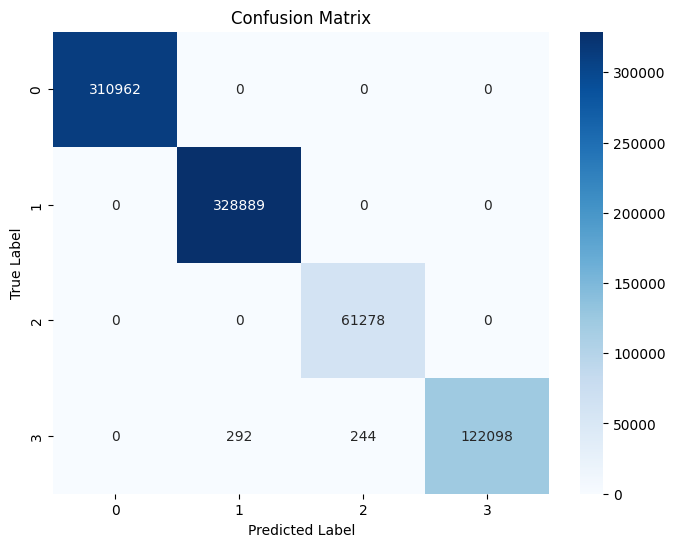

PyTorch model evaluation complete!


In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
#seaborn is is installed for plotting

print("Evaluating PyTorch model on the validation set...")

pytorch_model.eval() # Set the model to evaluation mode
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = pytorch_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# Generate confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("PyTorch model evaluation complete!")